# binary Magic

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,recall_score, precision_score, f1_score

In [10]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Dell\magic_project\binary_magic.csv",skiprows=1, header=1)
df.head()

,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.011,-8.2027,40.092,81.8828,g
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.261,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.788,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.737,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.462,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.098,g


In [11]:
df.head()


,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.011,-8.2027,40.092,81.8828,g
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.261,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.788,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.737,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.462,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.098,g


In [12]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 19019
Columns: 11


In [13]:
print(df.columns)

Index(['28.7967', '16.0021', '2.6449', '0.3918', '0.1982', '27.7004', '22.011',
       '-8.2027', '40.092', '81.8828', 'g'],
      dtype='str')


In [14]:
print(df.columns.tolist())

['28.7967', '16.0021', '2.6449', '0.3918', '0.1982', '27.7004', '22.011', '-8.2027', '40.092', '81.8828', 'g']


In [15]:
df.columns = [
    "Flength",
    "Fwidth",
    "Fsize",
    "Fconc",
    "Fconc1",
    "Fasym",
    "Fm3long",
    "Fm3trans",
    "Falpha",
    "Fdist",
    "Class"
]

print(df.columns.tolist())

['Flength', 'Fwidth', 'Fsize', 'Fconc', 'Fconc1', 'Fasym', 'Fm3long', 'Fm3trans', 'Falpha', 'Fdist', 'Class']


In [16]:
df.head()

,Flength,Fwidth,Fsize,Fconc,Fconc1,Fasym,Fm3long,Fm3trans,Falpha,Fdist,Class
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.261,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.788,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.737,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.462,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.098,g


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19019 entries, 0 to 19018
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Flength   19019 non-null  float64
 1   Fwidth    19019 non-null  float64
 2   Fsize     19019 non-null  float64
 3   Fconc     19019 non-null  float64
 4   Fconc1    19019 non-null  float64
 5   Fasym     19019 non-null  float64
 6   Fm3long   19019 non-null  float64
 7   Fm3trans  19019 non-null  float64
 8   Falpha    19019 non-null  float64
 9   Fdist     19019 non-null  float64
 10  Class     19019 non-null  str    
dtypes: float64(10), str(1)
memory usage: 1.6 MB


In [18]:
print("Total missing values in the dataset:", df.isnull().sum().sum())

Total missing values in the dataset: 0


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 115


In [20]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 18904


In [21]:
print(df["Class"].value_counts())

Class
g    12331
h     6573
Name: count, dtype: int64


In [22]:
print(df["Class"].value_counts(normalize=True)*100)

Class
g    65.229581
h    34.770419
Name: proportion, dtype: float64


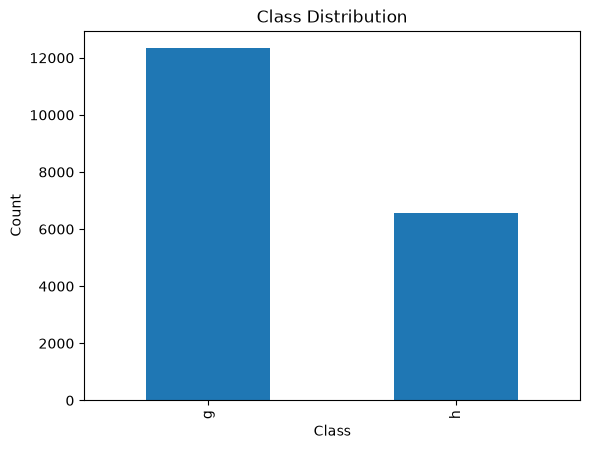

In [24]:
import matplotlib.pyplot as plt
df["Class"].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [25]:
df.describe()

,Flength,Fwidth,Fsize,Fconc,Fconc1,Fasym,Fm3long,Fm3trans,Falpha,Fdist
count,18904.000000,18904.000000,18904.000000,18904.000000,18904.000000,18904.000000,18904.000000,18904.000000,18904.000000,18904.000000
mean,53.162704,22.146197,2.824653,0.380247,0.214561,-4.179553,10.618224,0.259812,27.550981,193.718469
std,42.260535,18.301093,0.472387,0.182714,0.110386,59.011164,50.901966,20.775727,26.083586,74.683258
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
25%,24.356500,11.874100,2.477100,0.235800,0.128500,-20.479425,-12.771025,-10.836325,5.516050,142.277775
50%,37.131550,17.145250,2.740000,0.353950,0.196400,4.057200,15.336150,0.774350,17.532400,191.832550
75%,69.978650,24.712700,3.101100,0.503500,0.285025,24.123900,35.873725,10.949850,45.707325,240.413500
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000


In [26]:
x = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (18904, 10)
Target shape: (18904,)


In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,
test_size=0.2, random_state=42, stratify=y)
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15123, 10)
X_test shape: (3781, 10)
y_train shape: (15123,)
y_test shape: (3781,)


In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
print("Class:", le.classes_)
print("y_train:",y_train[:10])
print("y_test:",y_test[:10])

Class: ['g' 'h']
y_train: [1 1 0 0 1 1 0 1 0 0]
y_test: [0 0 0 0 1 0 0 0 0 0]


In [30]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [31]:
y_pred = model.predict(x_test)
print(y_pred[:20])

[0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]


In [32]:
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)


Accuracy: 0.790531605395398
Recall: 0.5802281368821293
Precision: 0.7607178464606181
F1 Score: 0.6583261432269197


In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2226  240]
 [ 552  763]]


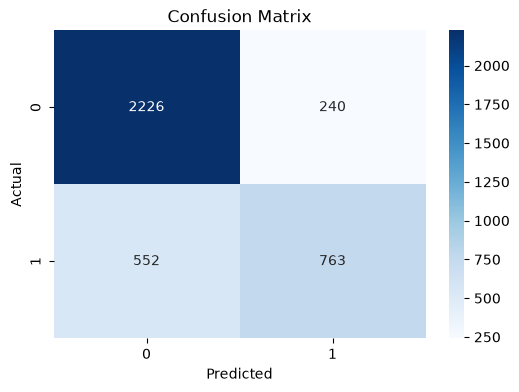

In [34]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [35]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85      2466
           1       0.76      0.58      0.66      1315

    accuracy                           0.79      3781
   macro avg       0.78      0.74      0.75      3781
weighted avg       0.79      0.79      0.78      3781



In [36]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
dt_pred = dt_model.predict(x_test)
print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [37]:
# model comparison
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, dt_pred)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test, dt_pred)],
    "Precision": [precision_score(y_test, y_pred), precision_score(y_test, dt_pred)],
    "F1 Score": [f1_score(y_test, y_pred), f1_score(y_test, dt_pred)]
})
print(comparison_df)

                 Model  Accuracy    Recall  Precision  F1 Score
0  Logistic Regression  0.790532  0.580228   0.760718  0.658326
1        Decision Tree  0.814070  0.745247   0.727003  0.736012


In [43]:
Best_model = comparison_df.loc[
    comparison_df["F1 Score"].idxmax(),
    "Model"
]

best_f1 = comparison_df["F1 Score"].max()

print("Best Model:", Best_model)
print("Best F1 Score:", best_f1)

Best Model: Decision Tree
Best F1 Score: 0.7360120165227187


In [44]:
import pickle
# save the best model
with open("best_model.pkl", "wb") as f:
    pickle.dump(model, f)  
print("Best model saved successfully as 'best_model.pkl'")

Best model saved successfully as 'best_model.pkl'


In [47]:
print("Number of features:", x.shape[1])
print("fetures:")
print(x.columns.tolist())

Number of features: 10
fetures:
['Flength', 'Fwidth', 'Fsize', 'Fconc', 'Fconc1', 'Fasym', 'Fm3long', 'Fm3trans', 'Falpha', 'Fdist']
